Mounted at /content/drive
(25059, 35)

Research Question:

Which patient characteristics
are associated with poor outcomes?


Mortality Rate
0.08372241510036314

Readmission Rate
0.14860928209425756

Sepsis Rate
0.12043577157907338

Ventilation Rate
0.08096891336445987
age_group
18-40    0.080635
41-60    0.085113
61-80    0.086541
80+      0.082770
Name: mortality_90d, dtype: float64


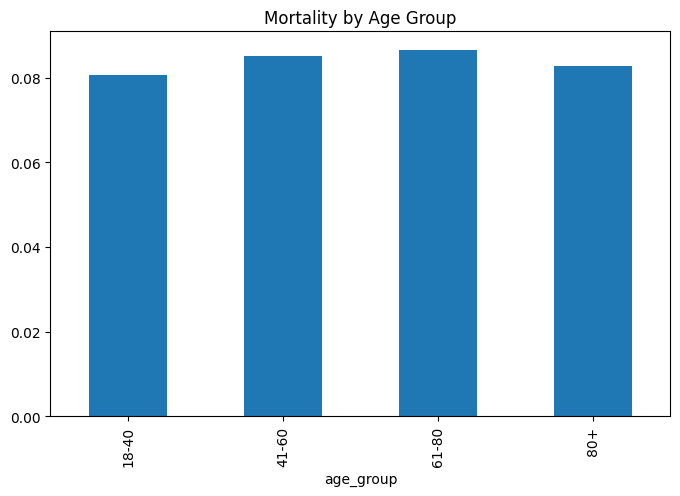

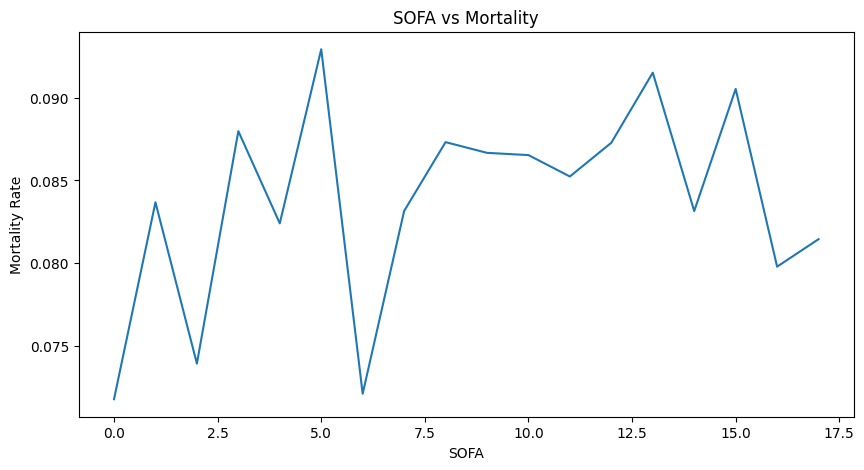

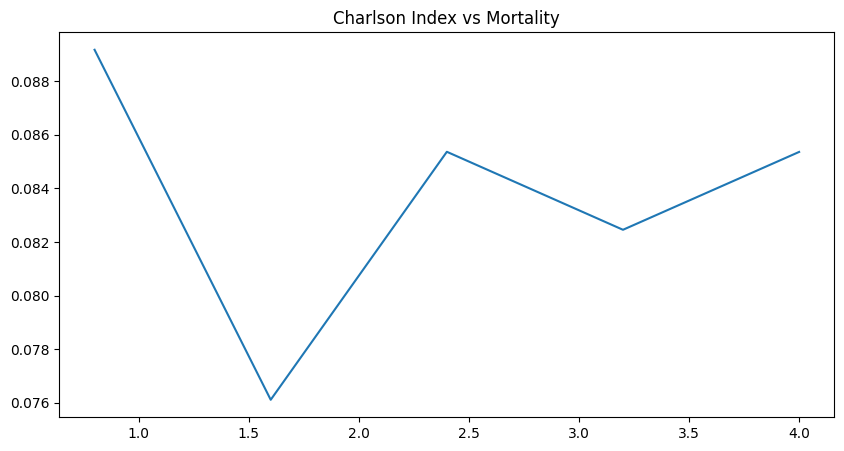

mortality_90d            1.000000
los_days                 0.166417
long_stay                0.146039
mortality                0.029316
icu_los                  0.015797
sofa                     0.007531
sepsis                   0.005899
subject_id               0.005458
hadm_id                  0.005453
Diabetes                 0.005406
resource_score           0.005344
num_labs                 0.004988
num_medications          0.004521
anchor_age               0.004520
COPD                     0.003657
high_resource_patient    0.001204
ventilation              0.000595
readmit_30d              0.000493
CKD                     -0.000216
num_diagnoses           -0.000844
Name: mortality_90d, dtype: float64


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4590
           1       0.00      0.00      0.00       422

    accuracy                           0.92      5012
   macro avg       0.46      0.50      0.48 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

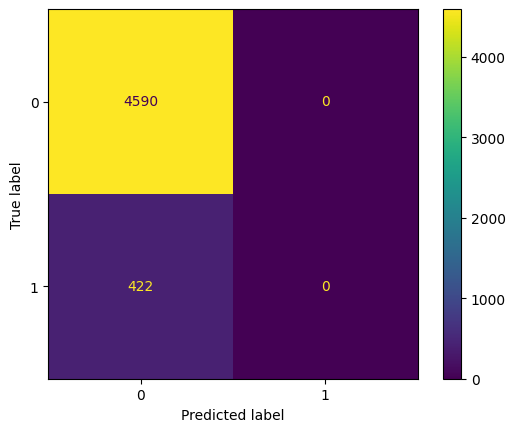

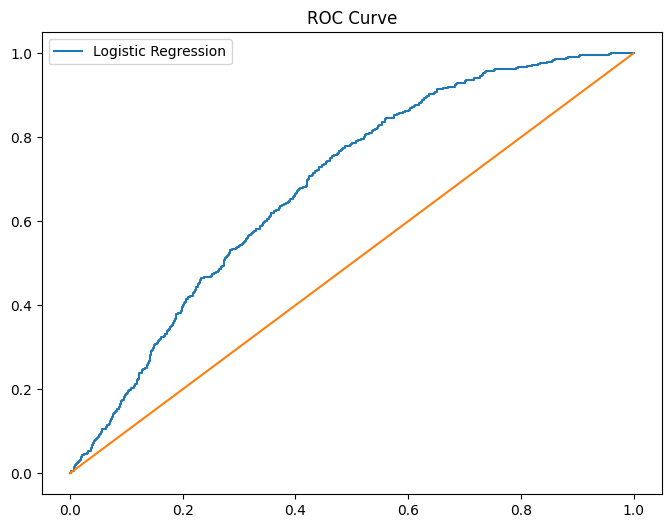

           Feature  Coefficient
9         los_days     0.115374
8          icu_los     0.020340
4  num_medications     0.011123
6         num_labs     0.007709
2             sofa     0.005576
3    num_diagnoses     0.005235
1   charlson_index     0.004188
0       anchor_age     0.000277
7   resource_score    -0.004577
5   num_procedures    -0.023409


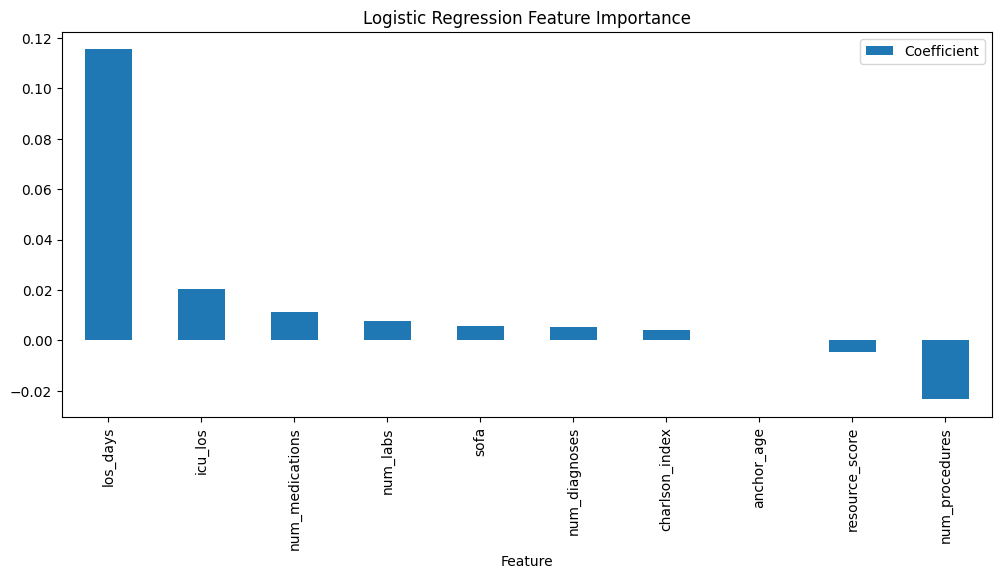



RANDOM FOREST
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4590
           1       0.00      0.00      0.00       422

    accuracy                           0.92      5012
   macro avg       0.46      0.50      0.48      5012
weighted avg       0.84      0.92      0.88      5012

Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.62220595979308
           Feature  Importance
8          icu_los    0.208482
0       anchor_age    0.163829
2             sofa    0.115700
9         los_days    0.106179
7   resource_score    0.105989
6         num_labs    0.098655
4  num_medications    0.072634
5   num_procedures    0.048098
1   charlson_index    0.040585
3    num_diagnoses    0.039850


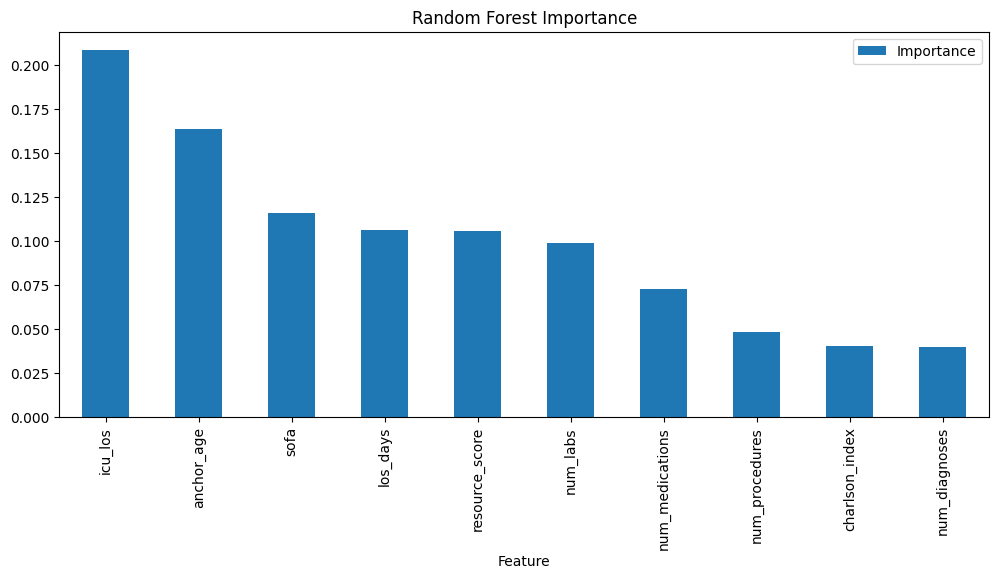



TOP RISK FACTORS
           Feature  Importance
8          icu_los    0.208482
0       anchor_age    0.163829
2             sofa    0.115700
9         los_days    0.106179
7   resource_score    0.105989
6         num_labs    0.098655
4  num_medications    0.072634
5   num_procedures    0.048098
1   charlson_index    0.040585
3    num_diagnoses    0.039850

Feature importance exported.


In [ ]:
# =====================================================
# NOTEBOOK 4
# PATIENT OUTCOME ANALYTICS
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# =====================================================
# LOAD DATA
# =====================================================

DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print(master.shape)

master.head()

# =====================================================
# RESEARCH QUESTION
# =====================================================

print("""
Research Question:

Which patient characteristics
are associated with poor outcomes?
""")

# =====================================================
# OUTCOME SUMMARY
# =====================================================

print("\nMortality Rate")

print(
    master["mortality_90d"].mean()
)

print("\nReadmission Rate")

print(
    master["readmit_30d"].mean()
)

print("\nSepsis Rate")

print(
    master["sepsis"].mean()
)

print("\nVentilation Rate")

print(
    master["ventilation"].mean()
)

# =====================================================
# AGE ANALYSIS
# =====================================================

age_mortality = (
    master.groupby("age_group")
    ["mortality_90d"]
    .mean()
)

print(age_mortality)

age_mortality.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Mortality by Age Group"
)

plt.show()

# =====================================================
# SOFA ANALYSIS
# =====================================================

sofa_mortality = (
    master.groupby("sofa")
    ["mortality_90d"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    sofa_mortality.index,
    sofa_mortality.values
)

plt.title(
    "SOFA vs Mortality"
)

plt.xlabel("SOFA")

plt.ylabel("Mortality Rate")

plt.show()

# =====================================================
# CHARLSON ANALYSIS
# =====================================================

charlson_mortality = (
    master.groupby(
        "charlson_index"
    )["mortality_90d"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    charlson_mortality.index,
    charlson_mortality.values
)

plt.title(
    "Charlson Index vs Mortality"
)

plt.show()

# =====================================================
# CORRELATIONS
# =====================================================

numeric_cols = master.select_dtypes(
    include=np.number
).columns

corr = master[
    numeric_cols
].corr()

mortality_corr = (
    corr["mortality_90d"]
    .sort_values(
        ascending=False
    )
)

print(
    mortality_corr.head(20)
)

# =====================================================
# FEATURES
# =====================================================

features = [

    "anchor_age",

    "charlson_index",

    "sofa",

    "num_diagnoses",

    "num_medications",

    "num_procedures",

    "num_labs",

    "resource_score",

    "icu_los",

    "los_days"

]

X = master[features]

y = master["mortality_90d"]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

# =====================================================
# LOGISTIC REGRESSION
# =====================================================

print("\n")
print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

lr_preds = lr.predict(
    X_test
)

lr_probs = lr.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        lr_preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        lr_preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        lr_preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        lr_preds
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        lr_probs
    )
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    lr_preds
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

# =====================================================
# ROC CURVE
# =====================================================

fpr,tpr,_ = roc_curve(
    y_test,
    lr_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1]
)

plt.legend()

plt.title(
    "ROC Curve"
)

plt.show()

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({

    "Feature":features,

    "Coefficient":
    lr.coef_[0]

})

importance = importance.sort_values(
    "Coefficient",
    ascending=False
)

print(importance)

importance.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Logistic Regression Feature Importance"
)

plt.show()

# =====================================================
# RANDOM FOREST
# =====================================================

print("\n")
print("="*60)
print("RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(
    X_test
)

rf_probs = rf.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        rf_preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        rf_preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        rf_preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        rf_preds
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        rf_probs
    )
)

# =====================================================
# RANDOM FOREST IMPORTANCE
# =====================================================

rf_importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    rf.feature_importances_

})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    rf_importance
)

rf_importance.plot(

    x="Feature",

    y="Importance",

    kind="bar",

    figsize=(12,5)

)

plt.title(
    "Random Forest Importance"
)

plt.show()

# =====================================================
# TOP RISK FACTORS
# =====================================================

print("\n")
print("="*60)
print("TOP RISK FACTORS")
print("="*60)

print(
    rf_importance.head(10)
)

# =====================================================
# SAVE RESULTS
# =====================================================

rf_importance.to_csv(
    f"{DATA_PATH}/rf_feature_importance.csv",
    index=False
)

importance.to_csv(
    f"{DATA_PATH}/logistic_feature_importance.csv",
    index=False
)

print(
    "\nFeature importance exported."
)